In [2]:
import pandas as pd
import subprocess
import matplotlib.pyplot as plt

In [9]:
training_file = '../../data/microsoft_ltr/microsoft_ltr_train.txt' 
test_file = '../../data/microsoft_ltr/microsoft_ltr_test.txt' 

cmd_ranknet = f'java -jar ../../data/microsoft_ltr/RankLib-2.9.jar -train {training_file} -ranker 1 -save ../../data/microsoft_ltr/ranknet_model.txt'
cmd_lambdamart = f'java -jar ../../data/microsoft_ltr/RankLib-2.9.jar -train {training_file} -ranker 6 -save ../../data/microsoft_ltr/lambdamart_model.txt'
cmd_listnet = f'java -jar ../../data/microsoft_ltr/RankLib-2.9.jar -train {training_file} -ranker 7 -save ../../data/microsoft_ltr/listnet_model.txt'


In [14]:
try:
  print('Running RankLib to train ranknet model')
  result = subprocess.run(cmd_ranknet, shell=True, check=True, capture_output=True, text=True)
  print(result.stdout)
  print('Finished training ranknet model')
except subprocess.CalledProcessError as e:
  print("Error ocurred")
  print(e.stderr)

Running RankLib to train ranknet model

Discard orig. features
Training data:	../../data/microsoft_ltr/microsoft_ltr_train.txt
Feature vector representation: Dense.
Ranking method:	RankNet
Feature description file:	Unspecified. All features will be used.
Train metric:	ERR@10
Test metric:	ERR@10
Highest relevance label (to compute ERR): 4
Feature normalization: No
Model file: ../../data/microsoft_ltr/ranknet_model.txt

[+] RankNet's Parameters:
No. of epochs: 100
No. of hidden layers: 1
No. of hidden nodes per layer: 10
Learning rate: 5.0E-5


Reading feature file [../../data/microsoft_ltr/microsoft_ltr_train.txt]: 0... 
Reading feature file [../../data/microsoft_ltr/microsoft_ltr_train.txt]: 0... 
Reading feature file [../../data/microsoft_ltr/microsoft_ltr_train.txt]: 0... 
Reading feature file [../../data/microsoft_ltr/microsoft_ltr_train.txt]... [Done.]            
(266 ranked lists, 30000 entries read)
Initializing... [Done]
-----------------------------------------
Training starts

In [15]:
try:
  print('Running RankLib to train lambdamart model')
  result = subprocess.run(cmd_lambdamart, shell=True, check=True, capture_output=True, text=True)
  print(result.stdout)
  print('Finished training lambdamart model')
except subprocess.CalledProcessError as e:
  print("Error ocurred")
  print(e.stderr)

Running RankLib to train lambdamart model

Discard orig. features
Training data:	../../data/microsoft_ltr/microsoft_ltr_train.txt
Feature vector representation: Dense.
Ranking method:	LambdaMART
Feature description file:	Unspecified. All features will be used.
Train metric:	ERR@10
Test metric:	ERR@10
Highest relevance label (to compute ERR): 4
Feature normalization: No
Model file: ../../data/microsoft_ltr/lambdamart_model.txt

[+] LambdaMART's Parameters:
No. of trees: 1000
No. of leaves: 10
No. of threshold candidates: 256
Min leaf support: 1
Learning rate: 0.1
Stop early: 100 rounds without performance gain on validation data


Reading feature file [../../data/microsoft_ltr/microsoft_ltr_train.txt]: 0... 
Reading feature file [../../data/microsoft_ltr/microsoft_ltr_train.txt]: 0... 
Reading feature file [../../data/microsoft_ltr/microsoft_ltr_train.txt]: 0... 
Reading feature file [../../data/microsoft_ltr/microsoft_ltr_train.txt]... [Done.]            
(266 ranked lists, 30000 entri

In [16]:
try:
  print('Running RankLib to train listnet model')
  subprocess.run(cmd_listnet, shell=True, check=True, capture_output=True, text=True)
  print(result.stdout)
  print('Finished training listnet model')
except subprocess.CalledProcessError as e:
  print("Error ocurred")
  print(e.stderr)

Running RankLib to train listnet model

Discard orig. features
Training data:	../../data/microsoft_ltr/microsoft_ltr_train.txt
Feature vector representation: Dense.
Ranking method:	LambdaMART
Feature description file:	Unspecified. All features will be used.
Train metric:	ERR@10
Test metric:	ERR@10
Highest relevance label (to compute ERR): 4
Feature normalization: No
Model file: ../../data/microsoft_ltr/lambdamart_model.txt

[+] LambdaMART's Parameters:
No. of trees: 1000
No. of leaves: 10
No. of threshold candidates: 256
Min leaf support: 1
Learning rate: 0.1
Stop early: 100 rounds without performance gain on validation data


Reading feature file [../../data/microsoft_ltr/microsoft_ltr_train.txt]: 0... 
Reading feature file [../../data/microsoft_ltr/microsoft_ltr_train.txt]: 0... 
Reading feature file [../../data/microsoft_ltr/microsoft_ltr_train.txt]: 0... 
Reading feature file [../../data/microsoft_ltr/microsoft_ltr_train.txt]... [Done.]            
(266 ranked lists, 30000 entries 

In [7]:
ranknet_model = '../../data/microsoft_ltr/ranknet_model.txt'
lambdamart_model = '../../data/microsoft_ltr/lambdamart_model.txt' 
listnet_model = '../../data/microsoft_ltr/listnet_model.txt' 

In [10]:
cmd_test_ranknet_MRR = f'java -jar ../../data/microsoft_ltr/RankLib-2.9.jar -load {ranknet_model} -test {test_file} -metric2T RR@10'

try:
  print('Running RankLib to test ranknet model using MRR@10')
  result = subprocess.run(cmd_test_ranknet_MRR, shell=True, check=True, capture_output=True, text=True)
  print(result.stdout)
  print('Finished testing ranknet model using MRR@10')
except subprocess.CalledProcessError as e:
  print("Error ocurred")
  print(e.stderr)


Running RankLib to test ranknet model using MRR@10

Discard orig. features
Model file:	../../data/microsoft_ltr/ranknet_model.txt
Feature normalization: No
Test metric:	RR@10
Model:		RankNet

Reading feature file [../../data/microsoft_ltr/microsoft_ltr_test.txt]: 0... 
Reading feature file [../../data/microsoft_ltr/microsoft_ltr_test.txt]... [Done.]            
(88 ranked lists, 10000 entries read)
RR@10 on test data: 0.6067

Finished testing ranknet model using MRR@10


In [11]:
cmd_test_lambdamart_MRR = f'java -jar ../../data/microsoft_ltr/RankLib-2.9.jar -load {lambdamart_model} -test {test_file} -metric2T RR@10'

try:
  print('Running RankLib to test lambdamart model using MRR@10')
  result = subprocess.run(cmd_test_lambdamart_MRR, shell=True, check=True, capture_output=True, text=True)
  print(result.stdout)
  print('Finished testing lambdamart model using MRR@10')
except subprocess.CalledProcessError as e:
  print("Error ocurred")
  print(e.stderr)

Running RankLib to test lambdamart model using MRR@10

Discard orig. features
Model file:	../../data/microsoft_ltr/lambdamart_model.txt
Feature normalization: No
Test metric:	RR@10
Model:		LambdaMART

Reading feature file [../../data/microsoft_ltr/microsoft_ltr_test.txt]: 0... 
Reading feature file [../../data/microsoft_ltr/microsoft_ltr_test.txt]... [Done.]            
(88 ranked lists, 10000 entries read)
RR@10 on test data: 0.8376

Finished testing lambdamart model using MRR@10


In [12]:
cmd_test_listnet_MRR = f'java -jar ../../data/microsoft_ltr/RankLib-2.9.jar -load {listnet_model} -test {test_file} -metric2T RR@10'

try:
  print('Running RankLib to test listnet model using MRR@10')
  result = subprocess.run(cmd_test_listnet_MRR, shell=True, check=True, capture_output=True, text=True)
  print(result.stdout)
  print('Finished testing lambdamart model using MRR@10')
except subprocess.CalledProcessError as e:
  print("Error ocurred")
  print(e.stderr)

Running RankLib to test listnet model using MRR@10

Discard orig. features
Model file:	../../data/microsoft_ltr/listnet_model.txt
Feature normalization: No
Test metric:	RR@10
Model:		ListNet

Reading feature file [../../data/microsoft_ltr/microsoft_ltr_test.txt]: 0... 
Reading feature file [../../data/microsoft_ltr/microsoft_ltr_test.txt]... [Done.]            
(88 ranked lists, 10000 entries read)
RR@10 on test data: 0.5348

Finished testing lambdamart model using MRR@10


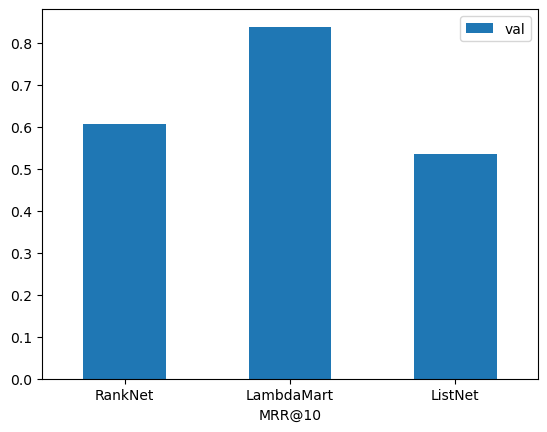

In [13]:
df = pd.DataFrame({"MRR@10": ["RankNet", "LambdaMart", "ListNet"], "val": [0.6067, 0.8376, 0.5348]})
ax = df.plot.bar(x="MRR@10", y="val", rot=0)

In [14]:
cmd_test_ranknet_NDCG = f'java -jar ../../data/microsoft_ltr/RankLib-2.9.jar -load {ranknet_model} -test {test_file} -metric2T NDCG@10'
try:
  print('Running RankLib to test ranknet model using NDCG@10')
  result = subprocess.run(cmd_test_ranknet_NDCG, shell=True, check=True, capture_output=True, text=True)
  print(result.stdout)
  print('Finished testing ranknet model using NDCG@10')
except subprocess.CalledProcessError as e:
  print("Error ocurred")
  print(e.stderr)

Running RankLib to test ranknet model using NDCG@10

Discard orig. features
Model file:	../../data/microsoft_ltr/ranknet_model.txt
Feature normalization: No
Test metric:	NDCG@10
Model:		RankNet

Reading feature file [../../data/microsoft_ltr/microsoft_ltr_test.txt]: 0... 
Reading feature file [../../data/microsoft_ltr/microsoft_ltr_test.txt]... [Done.]            
(88 ranked lists, 10000 entries read)
NDCG@10 on test data: 0.2171

Finished testing ranknet model using NDCG@10


In [15]:
cmd_test_lambdamart_NDCG = f'java -jar ../../data/microsoft_ltr/RankLib-2.9.jar -load {lambdamart_model} -test {test_file} -metric2T NDCG@10'
try:
  print('Running RankLib to test lambdamart model using NDCG@10')
  result = subprocess.run(cmd_test_lambdamart_NDCG, shell=True, check=True, capture_output=True, text=True)
  print(result.stdout)
  print('Finished testing lambdamart model using NDCG@10')
except subprocess.CalledProcessError as e:
  print("Error ocurred")
  print(e.stderr)

Running RankLib to test lambdamart model using NDCG@10

Discard orig. features
Model file:	../../data/microsoft_ltr/lambdamart_model.txt
Feature normalization: No
Test metric:	NDCG@10
Model:		LambdaMART

Reading feature file [../../data/microsoft_ltr/microsoft_ltr_test.txt]: 0... 
Reading feature file [../../data/microsoft_ltr/microsoft_ltr_test.txt]... [Done.]            
(88 ranked lists, 10000 entries read)
NDCG@10 on test data: 0.411

Finished testing lambdamart model using NDCG@10


In [16]:
cmd_test_listnet_NDCG = f'java -jar ../../data/microsoft_ltr/RankLib-2.9.jar -load {listnet_model} -test {test_file} -metric2T NDCG@10'
try:
  print('Running RankLib to test listnet model using NDCG@10')
  result = subprocess.run(cmd_test_listnet_NDCG, shell=True, check=True, capture_output=True, text=True)
  print(result.stdout)
  print('Finished testing listnet model using NDCG@10')
except subprocess.CalledProcessError as e:
  print("Error ocurred")
  print(e.stderr)

Running RankLib to test listnet model using NDCG@10

Discard orig. features
Model file:	../../data/microsoft_ltr/listnet_model.txt
Feature normalization: No
Test metric:	NDCG@10
Model:		ListNet

Reading feature file [../../data/microsoft_ltr/microsoft_ltr_test.txt]: 0... 
Reading feature file [../../data/microsoft_ltr/microsoft_ltr_test.txt]... [Done.]            
(88 ranked lists, 10000 entries read)
NDCG@10 on test data: 0.164

Finished testing listnet model using NDCG@10


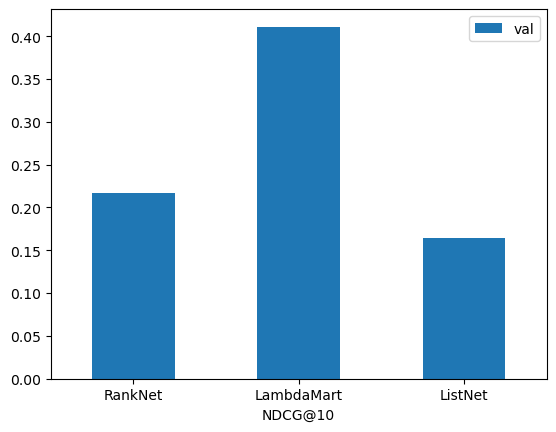

In [17]:
df = pd.DataFrame({"NDCG@10": ["RankNet", "LambdaMart", "ListNet"], "val": [0.2171, 0.411, 0.164]})
ax = df.plot.bar(x="NDCG@10", y="val", rot=0)

In [18]:
cmd_test_ranknet_P = f'java -jar ../../data/microsoft_ltr/RankLib-2.9.jar -load {ranknet_model} -test {test_file} -metric2T P@10'
try:
  print('Running RankLib to test ranknet model using P@10')
  result = subprocess.run(cmd_test_ranknet_P, shell=True, check=True, capture_output=True, text=True)
  print(result.stdout)
  print('Finished testing ranknet model using P@10')
except subprocess.CalledProcessError as e:
  print("Error ocurred")
  print(e.stderr)

Running RankLib to test ranknet model using P@10

Discard orig. features
Model file:	../../data/microsoft_ltr/ranknet_model.txt
Feature normalization: No
Test metric:	P@10
Model:		RankNet

Reading feature file [../../data/microsoft_ltr/microsoft_ltr_test.txt]: 0... 
Reading feature file [../../data/microsoft_ltr/microsoft_ltr_test.txt]... [Done.]            
(88 ranked lists, 10000 entries read)
P@10 on test data: 0.383

Finished testing ranknet model using P@10


In [19]:
cmd_test_lambdamart_P = f'java -jar ../../data/microsoft_ltr/RankLib-2.9.jar -load {lambdamart_model} -test {test_file} -metric2T P@10'
try:
  print('Running RankLib to test lambdamart model using P@10')
  result = subprocess.run(cmd_test_lambdamart_P, shell=True, check=True, capture_output=True, text=True)
  print(result.stdout)
  print('Finished testing lambdamart model using P@10')
except subprocess.CalledProcessError as e:
  print("Error ocurred")
  print(e.stderr)

Running RankLib to test lambdamart model using P@10

Discard orig. features
Model file:	../../data/microsoft_ltr/lambdamart_model.txt
Feature normalization: No
Test metric:	P@10
Model:		LambdaMART

Reading feature file [../../data/microsoft_ltr/microsoft_ltr_test.txt]: 0... 
Reading feature file [../../data/microsoft_ltr/microsoft_ltr_test.txt]... [Done.]            
(88 ranked lists, 10000 entries read)
P@10 on test data: 0.5852

Finished testing lambdamart model using P@10


In [20]:
cmd_test_listnet_P = f'java -jar ../../data/microsoft_ltr/RankLib-2.9.jar -load {listnet_model} -test {test_file} -metric2T P@10'
try:
  print('Running RankLib to test listnet model using P@10')
  result = subprocess.run(cmd_test_listnet_P, shell=True, check=True, capture_output=True, text=True)
  print(result.stdout)
  print('Finished testing listnet model using P@10')
except subprocess.CalledProcessError as e:
  print("Error ocurred")
  print(e.stderr)

Running RankLib to test listnet model using P@10

Discard orig. features
Model file:	../../data/microsoft_ltr/listnet_model.txt
Feature normalization: No
Test metric:	P@10
Model:		ListNet

Reading feature file [../../data/microsoft_ltr/microsoft_ltr_test.txt]: 0... 
Reading feature file [../../data/microsoft_ltr/microsoft_ltr_test.txt]... [Done.]            
(88 ranked lists, 10000 entries read)
P@10 on test data: 0.3739

Finished testing listnet model using P@10


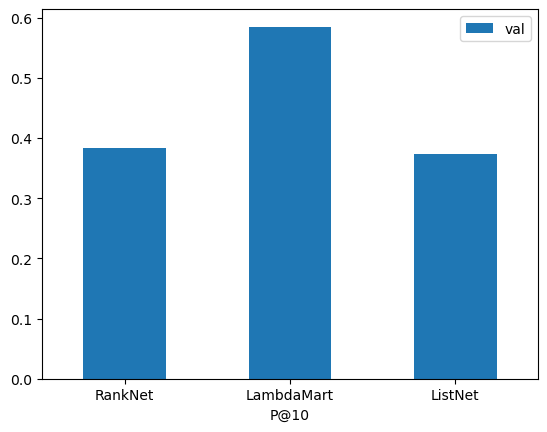

In [21]:
df = pd.DataFrame({"P@10": ["RankNet", "LambdaMart", "ListNet"], "val": [0.383, 0.5852, 0.3739]})
ax = df.plot.bar(x="P@10", y="val", rot=0)

### Reflections on result:
- Did you expect specific differences between models?

- Any remark about the results obtained across performance metrics?